# Homework 5: Diffusion Samplers

## Task 1: Theory (5 pts)

### Problem 1: KFP theorem (1 pt)

We have faced with 2 different formulations of Kolmogorov-Fokker-Planck theorem.

1) continuity equation in continuous-in-time NF:
$$
\frac{d \log p(\mathbf{x}(t), t)}{d t} = - \text{tr} \left( \frac{\partial f(\mathbf{x}, t)}{\partial \mathbf{x}} \right);
$$

2) the general form of the KFP equation in SDEs:
$$
\frac{\partial p(\mathbf{x}, t)}{\partial t} = - \text{div}\left(\mathbf{f}(\mathbf{x}, t) p(\mathbf{x}, t)\right) + \frac{1}{2} g^2(t) \Delta p(\mathbf{x}, t).
$$

In this task your goal is to prove that the first formulation is a special case of the more general second formulation.

**Note:** The derivation in the first formulation is total derivative (not partial).

Expand (1):
$$
    \frac{d \log p(\mathbf{x}, t)}{d t} = \frac{\partial \log p(\mathbf{x}, t)}{\partial t} + \frac{\partial \log p(\mathbf{x}, t)}{\partial \mathbf{x}} \frac{d \mathbf{x}}{d t} = \frac{\partial \log p(\mathbf{x}, t)}{\partial t} + \frac{\partial \log p(\mathbf{x}, t)}{\partial \mathbf{x}} f(\mathbf{x}, t)
$$
Assuming $g(t) = 0$, from (2) we get:
$$
    \frac{\partial p(\mathbf{x}, t)}{\partial t} = - \text{div}\left(\mathbf{f}(\mathbf{x}, t) p(\mathbf{x}, t)\right) = -\mathrm{tr} \left( f(\mathbf{x}, t) \nabla_{\mathbf{x}} p(\mathbf{x}, t)^\top + p(\mathbf{x}, t) \nabla_{\mathbf{x}} f(\mathbf{x}, t) \right) = -f(\mathbf{x}, t) \cdot \nabla_{\mathbf{x}} p(\mathbf{x}, t) - p(\mathbf{x}, t) \cdot \mathrm{div} f(\mathbf{x}, t)
$$
Divide both sides by $p(\mathbf{x}, t)$:
$$
    \frac{\partial \log p(\mathbf{x}, t)}{\partial t} = -f(\mathbf{x}, t) \cdot \nabla_{\mathbf{x}} \log p(\mathbf{x}, t) - \mathrm{div} f(\mathbf{x}, t)
$$
Substitute (1):
$$
    \frac{d \log p(\mathbf{x}, t)}{d t} = -\mathrm{div} f(\mathbf{x}, t) = -\mathrm{tr} \left( \frac{\partial f(\mathbf{x}, t)}{\partial \mathbf{x}} \right)
$$


### Problem 2: DDPM as SDE discretization (2 pts)

We have proved that DDPM is a discretization of the SDE
$$
	d \mathbf{x} = - \frac{1}{2} \beta(t) \mathbf{x}(t) dt + \sqrt{\beta(t)} \cdot d \mathbf{w}.
$$
Here $\mathbf{f}(\mathbf{x}, t) = - \frac{1}{2} \beta(t) \mathbf{x}(t)$, $g(t) = \sqrt{\beta(t)}$.

Recall reverse SDE
$$
    d\mathbf{x} = \left(\mathbf{f}(\mathbf{x}, t) - g^2(t) \frac{\partial \log p_t(\mathbf{x})}{\partial \mathbf{x}}\right) dt + g(t) d \mathbf{w}.
$$

The reverse SDE of the DDPM model will be
$$
    d\mathbf{x}(t) = -\beta(t)\left[\frac{x(t)}{2} + \nabla_{\mathbf{x}}\log p_t(\mathbf{x}(t))\right]dt + \sqrt{\beta(t)}d\mathbf{w}.
$$

The DDPM uses the following form of ancestral sampling
$$
\mathbf{x}_{t-1} = \frac{1}{\sqrt{1 - \beta_t}} \cdot \mathbf{x}_t + \frac{\beta_t}{\sqrt{1 - \beta_t}} \cdot \nabla_{\mathbf{x}_t} \log p(\mathbf{x}_t | \boldsymbol{\theta}) +  \sqrt{\beta_t} \cdot \boldsymbol{\epsilon}.
$$
(Here we assumed that $p(\mathbf{x}_{t - 1} | \mathbf{x}_t, \boldsymbol{\theta}) = \mathcal{N} \left(\boldsymbol{\mu}_{\boldsymbol{\theta}, t}(\mathbf{x}_t), \beta_t \cdot \mathbf{I}\right)$).

Here is your task to validate that DDPM iterative update scheme is actually discretization of SDE by letting $t \in \{0,\ldots,\frac{N-1}{N}\}$, $\Delta t = 1/N$, $\mathbf{x}(t-\Delta t) = \mathbf{x}_{s-1}$, $\mathbf{x}(t) = \mathbf{x}_s$, and $\beta(t)\Delta t = \beta_s$, s.e.:

In this task your goal is to show that the ancestral sampling is a discretization of the DDPM reverse SDE.

**Hints**:
1. use $dt < 0$;
2. $\beta_t = - \beta(t) dt$;
3. $d\mathbf{w} = \boldsymbol{\epsilon} \cdot \sqrt{-dt}$;
4. drop the terms with the order of $o(dt)$.

Evaluate temporal difference of ancestral sampling:
$$
    \mathbf{x}_{s-1} - \mathbf{x}_s = \left( \frac{1}{\sqrt{1 - \beta_s}} - 1 \right) \mathbf{x}_s + \frac{\beta_s}{\sqrt{1 - \beta_s}} \nabla_{\mathbf{x}_s} \log p(\mathbf{x}_s | \boldsymbol{\theta}) +  \sqrt{\beta_s} \cdot \boldsymbol{\epsilon}
$$

Only coefficients where we will require first-order approximation include $\beta_s$. $o(\beta_s) = o(-\beta(t)dt) = o(dt)$. Use first-order approximation for coefficients:

$$
    \mathbf{x}_{s-1} - \mathbf{x}_s = \frac{\beta_s}{2} \mathbf{x}_s + \beta_s \nabla_{\mathbf{x}_s} \log p(\mathbf{x}_t | \boldsymbol{\theta}) + \sqrt{\beta_s} \boldsymbol{\epsilon}
$$

Substitute $\beta_s = - \beta(t) dt$, $\mathbf{\epsilon} \sqrt{-dt} = d \mathbf{w}$, $\mathbf{x}_{s-1} - \mathbf{x}_s = d \mathbf{x}$:

$$
    d \mathbf{x} = -\beta(t) \left[ \frac{x(t)}{2} + \nabla_{\mathbf{x}_t} \log p(\mathbf{x}_t | \boldsymbol{\theta}) \right] dt + \sqrt{\beta(t)} d \mathbf{w}
$$

### Problem 3: Covariance of the Forward SDE (2 pts)

From [Lecture 9](https://github.com/r-isachenko/2026-DGM-AIMasters-course/blob/main/lectures/lecture9/Lecture9.pdf) we know that the forward SDE

$$
d\mathbf{x}= \mathbf{f}(\mathbf{x},t)\,dt + g(t)\,d\mathbf{w}
$$

has conditional moments

$$
\frac{d}{dt}\mu\bigl(\mathbf{x}(t),\mathbf{x}(0)\bigr)
 = \mathbb{E}\bigl[\mathbf{f}\bigl(\mathbf{x}(t),t\bigr)|\mathbf{x}(0)\bigr],
$$

$$
\frac{d}{dt}\Sigma\bigl(\mathbf{x}(t),\mathbf{x}(0)\bigr)
 = \mathbb{E}\bigl[\mathbf{f}\,(\mathbf{x}(t)-\mu)^{\top}+(\mathbf{x}(t)-\mu)\mathbf{f}^{\top}|\mathbf{x}(0)\bigr] + g^{2}(t)\mathbf{I}.
$$

Your goal is to prove the covariance identity shown above.


```
your solution
```

In [1]:
COMMIT_HASH = "1ecc005234d1a57d8d52e7a852ebe239cb0f9860"

!if [ -d dgm_utils ]; then rm -Rf dgm_utils; fi
!git clone https://github.com/r-isachenko/dgm_utils.git
%cd dgm_utils
!git checkout {COMMIT_HASH}
!pip install ./
%cd ./..
!rm -Rf dgm_utils

!if [ -d 2026-DGM-AIMasters-course ]; then rm -Rf 2026-DGM-AIMasters-course; fi
!git clone https://github.com/r-isachenko/2026-DGM-AIMasters-course.git
%cd 2026-DGM-AIMasters-course
!git lfs install
!git lfs pull --include="homeworks/cond_ddpm.pt2"
%cd ./..
!mv 2026-DGM-AIMasters-course/homeworks/cond_ddpm.pt2 .
!rm -Rf 2026-DGM-AIMasters-course

Cloning into 'dgm_utils'...
remote: Enumerating objects: 222, done.
remote: Counting objects: 100% (222/222), done.
remote: Compressing objects: 100% (170/170), done.
remote: Total 222 (delta 145), reused 98 (delta 52), pack-reused 0 (from 0)
Receiving objects: 100% (222/222), 53.74 KiB | 1.01 MiB/s, done.
Resolving deltas: 100% (145/145), done.
/content/dgm_utils
Note: switching to '1ecc005234d1a57d8d52e7a852ebe239cb0f9860'.

You are in 'detached HEAD' state. You can look around, make experimental
changes and commit them, and you can discard any commits you make in this
state without impacting any branches by switching back to a branch.

If you want to create a new branch to retain commits you create, you may
do so (now or later) by using -c with the switch command. Example:

  git switch -c <new-branch-name>

Or undo this operation with:

  git switch -

Turn off this advice by setting config variable advice.detachedHead to false

HEAD is now at 1ecc005 Add torchmetrics dependency in

In [2]:
from dgm_utils import load_dataset, BaseModel
from dgm_utils import visualize_images, show_samples

In [3]:
from typing import Optional, Tuple
from tqdm.auto import tqdm

import numpy as np

import torch
import torch.nn as nn
from torch.utils import data
from torchmetrics.image.fid import FrechetInceptionDistance as FID

if torch.cuda.is_available():
    DEVICE = "cuda"
    print('GPU found :)') 
else: 
    DEVICE = "cpu"
    print('GPU not found :(')

GPU found :)


## Task 1: FID and Predictor Sampler (2 pts)

Below you see the utility function, which broadcasts tensors. Look carefully at this code, we will use it in the majority of methods.

In [4]:
def extract_into_tensor(arr: torch.Tensor, indices: torch.Tensor, broadcast_shape: torch.Size) -> torch.Tensor:
    assert len(arr.shape) == 1
    res = arr.to(device=indices.device)[indices].float()
    while len(res.shape) < len(broadcast_shape):
        res = res[..., None]

    return res.expand(broadcast_shape)

### Forward Diffusion

Recall from previous homework and lectures that forward diffusion is a Markov chain
$$
    q(\mathbf{x}_t | \mathbf{x}_{t-1})
    =
    \mathcal{N}\left(
    \mathbf{x}_t | \sqrt{1-\beta_t}\mathbf{x}_{t-1}, \beta_t \mathbf{I}
    \right),
$$
where $\beta_t$ is a desired scheduler.

Also, for
$$
    \alpha_t = 1 - \beta_t,
    \qquad
    \bar{\alpha}_t = \prod_{s=1}^t \alpha_s,
$$
we have the closed form
$$
    q(\mathbf{x}_t | \mathbf{x}_0)
    =
    \mathcal{N}\left(
    \mathbf{x}_t | \sqrt{\bar{\alpha}_t}\mathbf{x}_0, (1-\bar{\alpha}_t)\mathbf{I}
    \right).
$$

The following class introduces these parameters.

In [5]:
class BaseDiffusion:
    def __init__(self, num_timesteps: int):
        self.num_timesteps = num_timesteps
        self.betas = self._get_beta_schedule(num_timesteps)
        self.alphas = 1 - self.betas
        self.alphas_cumprod = torch.cumprod(self.alphas, dim=-1)

    @staticmethod
    def _get_beta_schedule(num_diffusion_timesteps: int, s: float = 0.008):
        def f(t, T):
            return (np.cos((t / T + s) / (1 + s) * np.pi / 2)) ** 2

        alphas = []
        f0 = f(0, num_diffusion_timesteps)

        for t in range(num_diffusion_timesteps + 1):
            alphas.append(f(t, num_diffusion_timesteps) / f0)

        betas = []

        for t in range(1, num_diffusion_timesteps + 1):
            betas.append(min(1 - alphas[t] / alphas[t - 1], 0.999))

        return torch.from_numpy(np.array(betas)).double()

### Reverse Diffusion

Recall that reverse diffusion gradually denoises a sample starting from Gaussian noise, with $p(\mathbf{x}_T) = \mathcal{N}(0, \mathbf{I})$. It is also defined as a Markov chain
$$
    p(\mathbf{x}_{0:T}) = p(\mathbf{x}_T)\prod_{t=1}^T p(\mathbf{x}_{t-1}| \mathbf{x}_t),
    \qquad
    p(\mathbf{x}_{t-1}| \mathbf{x}_t) = \mathcal{N}\bigl(\boldsymbol{\mu}_t(\mathbf{x}_t), \sigma_t^2(\mathbf{x}_t)\bigr).
$$

From previous lectures and homework, for the forward process we know that
$$
    q(\mathbf{x}_{t-1}| \mathbf{x}_t, \mathbf{x}_0)
    =
    \mathcal{N}\bigl(\boldsymbol{\mu}(\mathbf{x}_t, \mathbf{x}_0), \tilde{\beta}_t \mathbf{I}\bigr),
$$
where $\tilde{\beta}_t = \frac{1-\bar{\alpha}_{t-1}}{1-\bar{\alpha}_t}\beta_t$ and
$$
    \boldsymbol{\mu}(\mathbf{x}_t, \mathbf{x}_0)
    =
    \frac{\sqrt{\alpha_t}(1-\bar{\alpha}_{t-1})}{1-\bar{\alpha}_t}\mathbf{x}_t
    +
    \frac{\sqrt{\bar{\alpha}_{t-1}}\beta_t}{1-\bar{\alpha}_t}\mathbf{x}_0.
$$

Also, since $\mathbf{x}_t = \sqrt{\bar{\alpha}_t}\mathbf{x}_0 + \sqrt{1-\bar{\alpha}_t}\boldsymbol{\epsilon}$, we can recover
$$
    \mathbf{x}_0
    =
    \frac{\mathbf{x}_t-\sqrt{1-\bar{\alpha}_t}\boldsymbol{\epsilon}}{\sqrt{\bar{\alpha}_t}}.
$$

In the current implementation, we also allow skipping steps and sample from $q(\mathbf{x}_s | \mathbf{x}_t, \mathbf{x}_0)$ for arbitrary $s \le t$. In this case,
$$
    q(\mathbf{x}_s | \mathbf{x}_t, \mathbf{x}_0)
    =
    \mathcal{N}\bigl(\boldsymbol{\mu}_{t \to s}(\mathbf{x}_t, \mathbf{x}_0), \tilde{\beta}_{t \to s}\mathbf{I}\bigr),
$$
where
$$
    \boldsymbol{\mu}_{t \to s}(\mathbf{x}_t, \mathbf{x}_0)
    =
    \sqrt{\frac{\bar{\alpha}_t}{\bar{\alpha}_s}}
    \frac{1-\bar{\alpha}_s}{1-\bar{\alpha}_t}\mathbf{x}_t
    +
    \frac{\bar{\alpha}_s-\bar{\alpha}_t}{\sqrt{\bar{\alpha}_s}(1-\bar{\alpha}_t)}\mathbf{x}_0
$$
and
$$
    \tilde{\beta}_{t \to s}
    =
    \frac{1-\bar{\alpha}_s}{1-\bar{\alpha}_t}
    \left(1-\frac{\bar{\alpha}_t}{\bar{\alpha}_s}\right).
$$

So our implementation can move not only from $t$ to $t-1$, but more generally from $t$ to any earlier timestep $s \le t$ from the time grid.

In [6]:
class ReverseDiffusion(BaseDiffusion):
    def __init__(self, *args, clip_range: Optional[Tuple[float, float]] = None, **kwargs):
        super().__init__(*args, **kwargs)
        self.clip_range = clip_range
        self.alphas_cumprod_prev = torch.cat([torch.tensor([1.0], device=self.betas.device), self.alphas_cumprod[:-1]], dim=0)

        # ====
        # your code
        # compute the variance in q(x_{t-1} | x_t, x_0)

        # ====
        self.tilde_beta = (1 - self.alphas_cumprod_prev) / (1 - self.alphas_cumprod) * self.betas

        # ====
        # your code
        # compute the coefficients in the mean of q(x_{t-1} | x_t, x_0)
        # so that mean = x_t_coef * x_t + x_0_coef * x_0

        # ====
        self.x_coef = torch.sqrt(self.alphas) * (1 - self.alphas_cumprod_prev) / (1 - self.alphas_cumprod)
        self.x0_coef = torch.sqrt(self.alphas_cumprod_prev) * self.betas / (1 - self.alphas_cumprod)

    def get_x0(self, xt: torch.Tensor, eps: torch.Tensor, t: torch.Tensor):
        # ====
        # your code
        # recover x_0 from x_t and eps

        # ====
        x0 = (xt - extract_into_tensor(torch.sqrt(1 - self.alphas_cumprod), t, xt.shape) * eps) / extract_into_tensor(torch.sqrt(self.alphas_cumprod), t, xt.shape)
        return x0.clamp(*self.clip_range) if self.clip_range is not None else x0

    def get_mean_variance(self, xt: torch.Tensor, eps: torch.Tensor, t: torch.Tensor):
        # ====
        # compute the mean and variance of q(x_{t-1} | x_t, x_0)
        # first recover x_0 from x_t and eps

        # ====
        mean = extract_into_tensor(self.x_coef, t, xt.shape) * xt + extract_into_tensor(self.x0_coef, t, xt.shape) * self.get_x0(xt, eps, t)
        variance = extract_into_tensor(self.tilde_beta, t, xt.shape)
        return mean, variance

    def get_samples(
        self,
        xt: torch.Tensor,
        eps: torch.Tensor,
        t: torch.Tensor,
        s: Optional[torch.Tensor] = None,
    ):
        if s is None:
            s = t - 1

        is_last_timestep = (s < 0).view([s.size(0)] + [1] * (xt.dim() - 1))
        s = torch.clamp(s, min=0)

        # ====
        # your code
        # 1) recover x_0 from x_t and eps
        # 2) compute the mean of q(x_s | x_t, x_0)
        # 3) compute the variance of q(x_s | x_t, x_0)
        # 4) sample with the reparameterization trick

        # ====
        x0 = self.get_x0(xt, eps, t)

        alpha_bar_t = extract_into_tensor(self.alphas_cumprod, t, xt.shape)
        alpha_bar_s = extract_into_tensor(self.alphas_cumprod, s, xt.shape)
        mean = torch.sqrt(alpha_bar_t / alpha_bar_s) * (1 - alpha_bar_s) / (1 - alpha_bar_t) * xt + (alpha_bar_s - alpha_bar_t) / (torch.sqrt(alpha_bar_s) * (1 - alpha_bar_t)) * x0
        variance = (1 - alpha_bar_s) / (1 - alpha_bar_t) * (1 - alpha_bar_t / alpha_bar_s)
        variance = torch.clamp(variance, min=0.0)
        noise = torch.randn_like(xt)
        sample = mean + torch.sqrt(variance) * noise
        sample = torch.where(is_last_timestep, x0, sample)
        return sample.float()


def test_reverse_diffusion():
    rdiff = ReverseDiffusion(num_timesteps=100)
    SHAPE = [2, 20]
    xt = torch.ones(SHAPE)
    eps = torch.ones(SHAPE)
    t = torch.ones((2,)).long() * 5

    x0 = rdiff.get_x0(xt=xt, eps=eps, t=t)
    assert list(x0.shape) == SHAPE
    assert np.allclose(x0.numpy(), np.ones(SHAPE) * 0.8999391)

    mean, variance = rdiff.get_mean_variance(xt=xt, eps=eps, t=t)
    assert list(mean.shape) == SHAPE
    assert list(variance.shape) == SHAPE
    assert np.allclose(mean.numpy(), np.ones(SHAPE) * 0.9723116)
    assert np.allclose(variance.numpy(), np.ones(SHAPE) * 0.00222036)

    x = rdiff.get_samples(xt, eps, t)
    assert list(x.shape) == SHAPE

    s_same = t.clone()
    x_same = rdiff.get_samples(xt, eps, t, s=s_same)
    assert list(x_same.shape) == SHAPE
    assert torch.allclose(x_same, xt.float())

    s_last = torch.ones((2,)).long() * -1
    x_last = rdiff.get_samples(xt, eps, t, s=s_last)
    assert list(x_last.shape) == SHAPE
    assert torch.allclose(x_last, x0.float())

    s_skip = torch.ones((2,)).long() * 2
    x_skip = rdiff.get_samples(xt, eps, t, s=s_skip)
    assert list(x_skip.shape) == SHAPE
    assert torch.isfinite(x_skip).all()


test_reverse_diffusion()

### Fréchet Inception Distance

To evaluate sample quality, we use Fréchet Inception Distance (FID).

The idea is simple: we pass real and generated images through a pretrained feature extractor, get feature vectors, and approximate their distributions with Gaussians. Then FID measures the distance between these two Gaussian distributions.

If $(\mu_r, \Sigma_r)$ are mean and covariance of real features, and $(\mu_g, \Sigma_g)$ are mean and covariance of generated features, then
$$
    \mathrm{FID}
    =
    \|\mu_r - \mu_g\|_2^2
    +
    \operatorname{Tr}\left(
    \Sigma_r + \Sigma_g - 2(\Sigma_r \Sigma_g)^{1/2}
    \right).
$$

Smaller FID usually means that generated samples are closer to real ones in the feature space.

We will use TorchMetrics for its computation. See [docs](https://lightning.ai/docs/torchmetrics/stable/pages/quickstart.html) on how to use it metric.

In [7]:
@torch.no_grad()
def compute_fid(
    metric: FID,
    sampler,
    num_samples: int,
    batch_size: int,
    **sample_kwargs
) -> float:
    remaining = num_samples
    pbar = tqdm(total=num_samples, desc="Sampling")
    while remaining > 0:
        cur_bs = min(batch_size, remaining)

        samples = sampler.sample(
            num_samples=cur_bs,
            **sample_kwargs
        )
        # ====
        # your code
        # accumulate features of samples
        
        # ====
        features = metric.update(samples, real=False)
        remaining -= cur_bs
        pbar.update(cur_bs)

    # ====
    # your code
    # compute FID and return float value
    
    # ====
    fid_value = metric.compute().item()
    return fid_value

In this homework, you will use a pretrained network that we kindly provide :) This is the DDPM model from the previous homework, trained on CIFAR10. 

To make the evaluation efficient, we precompute feature vectors for the real CIFAR10 data as follows.

100%|██████████| 170M/170M [00:05<00:00, 31.0MB/s] 


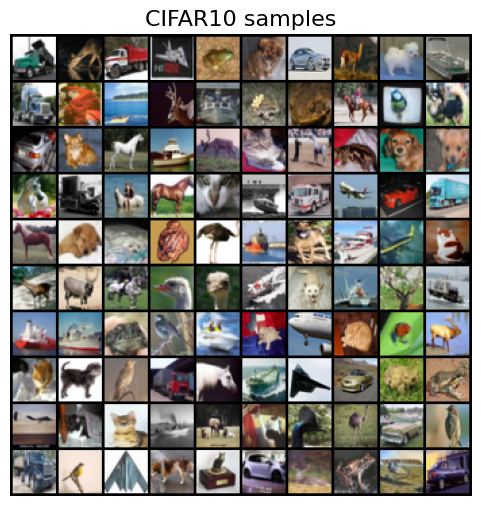

In [8]:
train_data, train_labels, test_data, test_labels = load_dataset("cifar10", flatten=False, binarize=False, with_targets=True)
visualize_images(train_data, "CIFAR10 samples")

Now let's compute statistics for the dataset.

In [9]:
# ====
# your code
# choose these parameters
BATCH_SIZE = 64
# ====

# ====
# your code
# initialize FID metric with reset_real_features=False
# see documentation for details: 
# https://lightning.ai/docs/torchmetrics/stable/image/frechet_inception_distance.html

# ====
fid_metric = FID(reset_real_features=False, normalize=True).to(DEVICE)

test_loader = data.DataLoader(test_data, batch_size=BATCH_SIZE, shuffle=False)
for batch in tqdm(test_loader):
    batch = batch.to(DEVICE)
    # ====
    # your code
    # accumulate real features
    
    # ====
    fid_metric.update(batch, real=True)
    

Downloading: "https://github.com/toshas/torch-fidelity/releases/download/v0.2.0/weights-inception-2015-12-05-6726825d.pth" to /root/.cache/torch/hub/checkpoints/weights-inception-2015-12-05-6726825d.pth
100%|██████████| 91.2M/91.2M [00:00<00:00, 372MB/s]


  0%|          | 0/157 [00:00<?, ?it/s]

Finally, let us implement the base Predictor sampler, which is essentially the same sampler as in the previous homework.

In [14]:
class PredictorSampler(BaseModel):
    def __init__(
        self,
        model: nn.Module,
        num_timesteps: int,
        shape: Tuple[int, int, int],
    ):
        super().__init__()
        self.model = model
        self.reverse_diffusion = ReverseDiffusion(num_timesteps=num_timesteps, clip_range=(-1.0, 1.0))
        self.num_timesteps = num_timesteps
        self.shape = shape

    def forward(
        self, x: torch.Tensor, t: torch.Tensor, y: Optional[torch.Tensor] = None
    ) -> torch.Tensor:
        if y is None:
            y = torch.zeros_like(t)
        return self.model(x, t, y)
        
    @torch.no_grad()
    def sample(
        self, 
        num_samples: int, 
        y: Optional[torch.Tensor] = None, 
        num_timesteps: Optional[int] = None,
        guidance_scale: float = 3.0
    ):
        if num_timesteps is None:
            num_timesteps = self.num_timesteps
        assert 1 <= num_timesteps <= self.num_timesteps

        x = torch.randn((num_samples, *self.shape), device=self.device, dtype=torch.float32)
        
        step = max(1, self.num_timesteps // num_timesteps)
        indices = torch.arange(
            self.num_timesteps - 1, -1, -step,
            device=x.device, dtype=torch.long,
        )
        if indices[-1].item() != 0:
            indices = torch.cat([indices, indices.new_tensor([0])])

        for k, i in enumerate(indices):
            t = torch.tensor([i] * num_samples, device=x.device)
            idx = -1 if k == len(indices) - 1 else int(indices[k + 1].item())
            s = torch.full((num_samples,), idx, device=x.device, dtype=torch.long)
            
            # ====
            # your code
            # 1) get epsilon from the model without conditioning
            # 2) if y is not None then 
            #    get epsilon from the model with conditioning
            #    modify epsilon with classifier-free guidance formula
            # 3) sample from the reverse diffusion
            
            # ====
            eps = self.forward(x, t)
            if y is not None:
                eps_cond = self.forward(x, t, y)
                eps = eps + guidance_scale * (eps_cond - eps)
            x = self.reverse_diffusion.get_samples(x, eps, t, s)
        return torch.clamp(0.5 * x + 0.5, 0.0, 1.0)
    
    def loss(self) -> None:
        pass

Let us check generation with the pretrained model.

**Note:** you can now choose any number of timesteps such that (1 < `NUM_TIMESTEPS` < 1000).

W0425 12:18:32.339000 1230 torch/export/__init__.py:454] Ran into the following error when deserializing
W0425 12:18:32.339000 1230 torch/export/__init__.py:454] Traceback (most recent call last):
W0425 12:18:32.339000 1230 torch/export/__init__.py:454]   File "/usr/local/lib/python3.12/dist-packages/torch/export/__init__.py", line 449, in load
W0425 12:18:32.339000 1230 torch/export/__init__.py:454]     pt2_contents = load_pt2(
W0425 12:18:32.339000 1230 torch/export/__init__.py:454]                    ^^^^^^^^^
W0425 12:18:32.339000 1230 torch/export/__init__.py:454]   File "/usr/local/lib/python3.12/dist-packages/torch/export/pt2_archive/_package.py", line 1098, in load_pt2
W0425 12:18:32.339000 1230 torch/export/__init__.py:454]     with PT2ArchiveReader(f) as archive_reader:
W0425 12:18:32.339000 1230 torch/export/__init__.py:454]          ^^^^^^^^^^^^^^^^^^^
W0425 12:18:32.339000 1230 torch/export/__init__.py:454]   File "/usr/local/lib/python3.12/dist-packages/torch/export/pt2_a

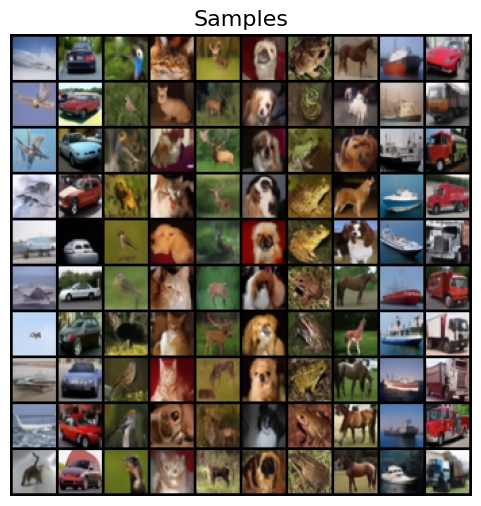

In [16]:
# ====
# your code
# choose these parameters
BATCH_SIZE = 64
NUM_TIMESTEPS = 25
# ====

model = torch.export.load("cond_ddpm.pt2").module()

sampler = PredictorSampler(
    model=model,
    num_timesteps=1000,
    shape=(3, 32, 32),
).to(DEVICE)

num_samples = 100
y = (torch.arange(num_samples) % 10).to(DEVICE)
samples = sampler.sample(
    num_samples=num_samples, y=y, num_timesteps=NUM_TIMESTEPS
).cpu().numpy()
show_samples(samples, title="Samples")

In [17]:
fid_metric.reset()
fid_value = compute_fid(
    fid_metric,
    sampler,
    num_samples=len(test_data),
    batch_size=BATCH_SIZE,
    num_timesteps=NUM_TIMESTEPS,
)
print(f"FID: {fid_value:.4f}")

Sampling:   0%|          | 0/10000 [00:00<?, ?it/s]

FID: 62.1424


## Task 3: Predictor-Corrector Sampler (4 pts)

Now let us extend the Predictor sampler with **correction** steps.

Recall from NCSN and Langevin dynamics that, if we know the score function $\nabla_{\mathbf{x}} \log p(\mathbf{x})$, we can refine samples by moving them towards regions of higher density and adding a small amount of noise.

The idea of Predictor-Corrector uses this knowledge:
- **Predictor** makes the usual reverse diffusion step from $\mathbf{x}_t$ to an earlier timestep.
- **Corrector** additionally refines the current sample at the same timestep $t$ before this transition.

To do this, we recover the score from the predicted noise $\boldsymbol{\epsilon}_{\theta,t}(\mathbf{x}_t, \mathbf{y})$. From the forward diffusion formula, at timestep $t$ we have
$$
    \nabla_{\mathbf{x}_t} \log q(\mathbf{x}_t)
    \approx
    -\frac{\boldsymbol{\epsilon}_{\theta,t}(\mathbf{x}_t, \mathbf{y})}{\sqrt{1-\bar{\alpha}_t}}.
$$

Then we apply a Langevin correction step using the Euler-Maruyama discretization:
$$
    \mathbf{x}_t
    \leftarrow
    \mathbf{x}_t + \eta_t \, \mathbf{s}_t + \sqrt{2\eta_t}\,\mathbf{z},
    \qquad
    \mathbf{s}_t
    =
    -\frac{\boldsymbol{\epsilon}_{\theta,t}(\mathbf{x}_t, \mathbf{y})}{\sqrt{1-\bar{\alpha}_t}},
    \qquad
    \mathbf{z}\sim\mathcal{N}(0,\mathbf{I}).
$$

In our implementation, the step size is chosen adaptively from the target signal-to-noise ratio:
$$
    \eta_t
    =
    2\left(
    \frac{\mathrm{target\_snr}\cdot \|\mathbf{z}\|_2}
    {\|\mathbf{s}_t\|_2}
    \right)^2,
$$
where in practice we use batch-average norms of the noise and the score.

This correction can be repeated several times at the same timestep. After that, we apply the usual Predictor step and move to an earlier timestep.

So, compared to the base Predictor sampler, Predictor-Corrector adds a few Langevin refinement steps before each reverse diffusion transition.

In [24]:
class PredictorCorrectorSampler(PredictorSampler):
    def __init__(
        self,
        model: nn.Module,
        num_timesteps: int,
        shape: Tuple[int, int, int],
    ):
        super().__init__(
            model=model,
            num_timesteps=num_timesteps,
            shape=shape,
        )
        
    @torch.no_grad()
    def sample(
        self,
        num_samples: int,
        y: Optional[torch.Tensor] = None,
        num_timesteps: Optional[int] = None,
        guidance_scale: float = 3.0,
        corrector_steps: int = 1,
        target_snr: float = 0.16,
    ):
        if num_timesteps is None:
            num_timesteps = self.num_timesteps
        assert 1 <= num_timesteps <= self.num_timesteps

        x = torch.randn((num_samples, *self.shape), device=self.device, dtype=torch.float32)
        
        step = max(1, self.num_timesteps // num_timesteps)
        indices = torch.arange(
            self.num_timesteps - 1, -1, -step,
            device=x.device, dtype=torch.long,
        )
        if indices[-1].item() != 0:
            indices = torch.cat([indices, indices.new_tensor([0])])

        for k, i in enumerate(indices):
            t = torch.tensor([i] * num_samples, device=x.device)
            idx = -1 if k == len(indices) - 1 else int(indices[k + 1].item())
            s = torch.full((num_samples,), idx, device=x.device, dtype=torch.long)

            alpha_bar_t = extract_into_tensor(
                self.reverse_diffusion.alphas_cumprod, t, x.shape
            )
            for _ in range(corrector_steps):
                # ====
                # your code
                # 1) get epsilon from the model without conditioning
                # 2) if y is not None then 
                #    get epsilon from the model with conditioning
                #    modify epsilon with classifier-free guidance formula
                # 3) convert it to the score estimate
                # 4) choose the Langevin step size from the target SNR
                # 5) update x with one Langevine step
                
                # ====
                eps = self.forward(x, t)
                z = torch.randn_like(x)
                if y is not None:
                    eps_cond = self.forward(x, t, y)
                    eps = eps + guidance_scale * (eps_cond - eps)

                score = -eps / torch.sqrt(1 - alpha_bar_t)
                nu = 2 * (target_snr * torch.norm(z) / torch.norm(score))**2
                x = x + nu * score + torch.sqrt(2 * nu) * z
            
            # ====
            # your code
            # 1) get epsilon from the model without conditioning
            # 2) if y is not None then 
            #    get epsilon from the model with conditioning
            #    modify epsilon with classifier-free guidance formula
            # 3) sample from the reverse diffusion
            
            # ====
            eps = self.forward(x, t)
            if y is not None:
                eps_cond = self.forward(x, t, y)
                eps = eps + guidance_scale * (eps_cond - eps)
            x = self.reverse_diffusion.get_samples(x, eps, t, s)

        return torch.clamp(0.5 * x + 0.5, 0.0, 1.0)

Let us check generation with the pretrained model and correction steps.

**Note:** before computing FID, it is recommended to first inspect the generated samples visually and choose the best parameters for sampling.

W0425 12:41:35.426000 1230 torch/export/__init__.py:454] Ran into the following error when deserializing
W0425 12:41:35.426000 1230 torch/export/__init__.py:454] Traceback (most recent call last):
W0425 12:41:35.426000 1230 torch/export/__init__.py:454]   File "/usr/local/lib/python3.12/dist-packages/torch/export/__init__.py", line 449, in load
W0425 12:41:35.426000 1230 torch/export/__init__.py:454]     pt2_contents = load_pt2(
W0425 12:41:35.426000 1230 torch/export/__init__.py:454]                    ^^^^^^^^^
W0425 12:41:35.426000 1230 torch/export/__init__.py:454]   File "/usr/local/lib/python3.12/dist-packages/torch/export/pt2_archive/_package.py", line 1098, in load_pt2
W0425 12:41:35.426000 1230 torch/export/__init__.py:454]     with PT2ArchiveReader(f) as archive_reader:
W0425 12:41:35.426000 1230 torch/export/__init__.py:454]          ^^^^^^^^^^^^^^^^^^^
W0425 12:41:35.426000 1230 torch/export/__init__.py:454]   File "/usr/local/lib/python3.12/dist-packages/torch/export/pt2_a

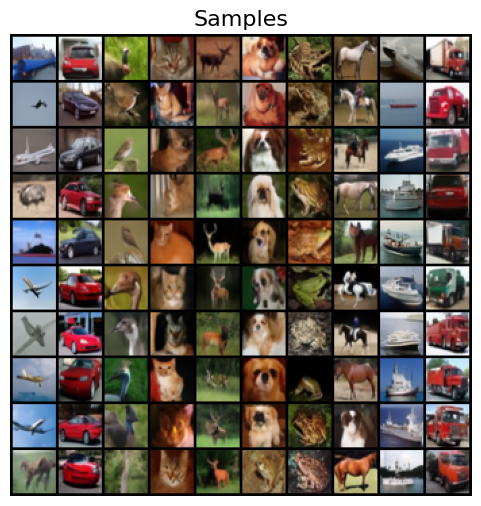

In [25]:
# ====
# your code
# choose these parameters
BATCH_SIZE = 64
NUM_TIMESTEPS = 25
CORRECTOR_STEPS = 1
TARGET_SNR = 0.16
# ====

model = torch.export.load("cond_ddpm.pt2").module()

sampler = PredictorCorrectorSampler(
    model=model,
    num_timesteps=1000,
    shape=(3, 32, 32),
).to(DEVICE)

num_samples = 100
y = (torch.arange(num_samples) % 10).to(DEVICE)
samples = sampler.sample(
    num_samples=num_samples, y=y,
    num_timesteps=NUM_TIMESTEPS, 
    corrector_steps=CORRECTOR_STEPS,
    target_snr=TARGET_SNR,
).cpu().numpy()
show_samples(samples, title="Samples")

In [26]:
fid_metric.reset()
fid_value = compute_fid(
    fid_metric,
    sampler,
    num_samples=len(test_data),
    batch_size=BATCH_SIZE,
    num_timesteps=NUM_TIMESTEPS,
    corrector_steps=CORRECTOR_STEPS,
    target_snr=TARGET_SNR,
)
print(f"FID: {fid_value:.4f}")

Sampling:   0%|          | 0/10000 [00:00<?, ?it/s]

FID: 58.2345


## Task 4: DDIM Sampler (4 pts)

Now let us consider the **DDIM sampler**.

The main difference from the Predictor sampler is that DDIM uses a **deterministic** update. As before, at timestep $t$ we first predict the noise $\boldsymbol{\epsilon}_{\theta,t}(\mathbf{x}_t, \mathbf{y})$ and recover
$$
    \hat{\mathbf{x}}_0
    =
    \frac{\mathbf{x}_t-\sqrt{1-\bar{\alpha}_t}\,\boldsymbol{\epsilon}_{\theta,t}(\mathbf{x}_t, \mathbf{y})}{\sqrt{\bar{\alpha}_t}}.
$$

Then, instead of sampling from a Gaussian transition, we directly move to an earlier timestep $s < t$ using
$$
    \mathbf{x}_s
    =
    \sqrt{\bar{\alpha}_s}\,\hat{\mathbf{x}}_0
    +
    \sqrt{1-\bar{\alpha}_s}\,\boldsymbol{\epsilon}_{\theta,t}(\mathbf{x}_t, \mathbf{y}).
$$

Such a construction defines a non-Markovian reverse process whose marginals are **consistent with the original forward diffusion process**. So DDIM keeps the same marginals as in DDPM, but uses a deterministic trajectory for sampling.


In [31]:
class DDIMSampler(PredictorSampler):
    def __init__(
        self,
        model: nn.Module,
        num_timesteps: int,
        shape: Tuple[int, int, int],
    ):
        super().__init__(
            model=model,
            num_timesteps=num_timesteps,
            shape=shape,
        )
        
    @torch.no_grad()
    def sample(
        self,
        num_samples: int,
        y: Optional[torch.Tensor] = None,
        num_timesteps: Optional[int] = None,
        guidance_scale: float = 3.0,
    ):
        if num_timesteps is None:
            num_timesteps = self.num_timesteps
        assert 1 <= num_timesteps <= self.num_timesteps

        x = torch.randn((num_samples, *self.shape), device=self.device, dtype=torch.float32)
        
        step = max(1, self.num_timesteps // num_timesteps)
        indices = torch.arange(
            self.num_timesteps - 1, -1,-step,
            device=x.device, dtype=torch.long,
        )
        if indices[-1].item() != 0:
            indices = torch.cat([indices, indices.new_tensor([0])])

        for k, i in enumerate(indices):
            t = torch.full((num_samples,), int(i.item()), device=x.device, dtype=torch.long)
            idx = -1 if k == len(indices) - 1 else int(indices[k + 1].item())
            s = torch.full((num_samples,), idx, device=x.device, dtype=torch.long)

            if idx >= 0:
                alpha_bar_s = extract_into_tensor(
                    self.reverse_diffusion.alphas_cumprod, s, x.shape
                )

            # ====
            # your code
            # 1) get epsilon from the model without conditioning
            # 2) if y is not None then 
            #    get epsilon from the model with conditioning
            #    modify epsilon with classifier-free guidance formula
            # 3) get x0 from the reverse diffusion
            # 4) update x with the determenistic DDIM formula
            
            # ====
            eps = self.forward(x, t)
            if y is not None:
                eps_cond = self.forward(x, t, y)
                eps = eps + guidance_scale * (eps_cond - eps)

            x0 = self.reverse_diffusion.get_x0(x, eps, t)

            if idx < 0:
                x = x0
            else:
                alpha_bar_s = extract_into_tensor(self.reverse_diffusion.alphas_cumprod, s, x.shape)
                x = torch.sqrt(alpha_bar_s) * x0 + torch.sqrt(1 - alpha_bar_s) * eps

        return torch.clamp(0.5 * x + 0.5, 0.0, 1.0)

W0425 13:19:30.640000 1230 torch/export/__init__.py:454] Ran into the following error when deserializing
W0425 13:19:30.640000 1230 torch/export/__init__.py:454] Traceback (most recent call last):
W0425 13:19:30.640000 1230 torch/export/__init__.py:454]   File "/usr/local/lib/python3.12/dist-packages/torch/export/__init__.py", line 449, in load
W0425 13:19:30.640000 1230 torch/export/__init__.py:454]     pt2_contents = load_pt2(
W0425 13:19:30.640000 1230 torch/export/__init__.py:454]                    ^^^^^^^^^
W0425 13:19:30.640000 1230 torch/export/__init__.py:454]   File "/usr/local/lib/python3.12/dist-packages/torch/export/pt2_archive/_package.py", line 1098, in load_pt2
W0425 13:19:30.640000 1230 torch/export/__init__.py:454]     with PT2ArchiveReader(f) as archive_reader:
W0425 13:19:30.640000 1230 torch/export/__init__.py:454]          ^^^^^^^^^^^^^^^^^^^
W0425 13:19:30.640000 1230 torch/export/__init__.py:454]   File "/usr/local/lib/python3.12/dist-packages/torch/export/pt2_a

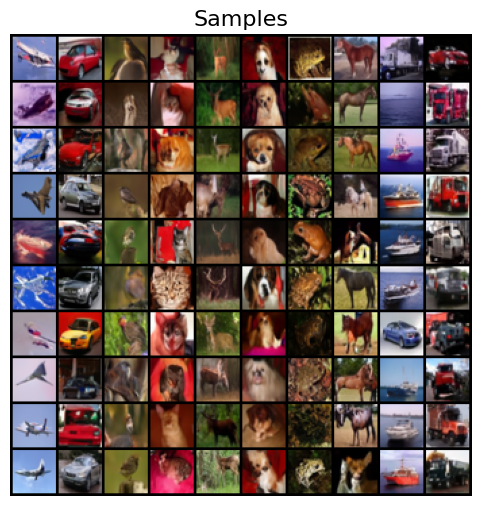

In [32]:
# ====
# your code
# choose these parameters
BATCH_SIZE = 64
NUM_TIMESTEPS = 25 
# ====

model = torch.export.load("cond_ddpm.pt2").module()

sampler = DDIMSampler(
    model=model,
    num_timesteps=1000,
    shape=(3, 32, 32),
).to(DEVICE)

num_samples = 100
y = (torch.arange(num_samples) % 10).to(DEVICE)
samples = sampler.sample(
    num_samples=num_samples, y=y,
    num_timesteps=NUM_TIMESTEPS, 
).cpu().numpy()
show_samples(samples, title="Samples")

In [33]:
fid_metric.reset()
fid_value = compute_fid(
    fid_metric,
    sampler,
    num_samples=len(test_data),
    batch_size=BATCH_SIZE,
    num_timesteps=NUM_TIMESTEPS,
)
print(f"FID: {fid_value:.4f}")

Sampling:   0%|          | 0/10000 [00:00<?, ?it/s]

FID: 67.2714
